<a href="https://colab.research.google.com/github/simulate111/TOPSIS_Thes/blob/main/TEA_ALgorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

# This will open an upload dialog below the cell
uploaded = files.upload()

Saving Turku_Full.csv to Turku_Full (1).csv


Loading data...

🏆 THE WINNING CONFIGURATIONS 🏆
--------------------------------------------------
🥇 SAW WINNER (Absolute Balanced Minimum):
   Architecture: PV:498.0kW | WT:35.0 | Bat:44
   Energy Price: $0.2254/kWh | CapEx: $1,661,210

🥇 VIKOR WINNER (Lowest Upfront CapEx):
   Architecture: PV:463.0kW | WT:35.0 | Bat:46
   Energy Price: $0.2255/kWh | CapEx: $1,648,243

🥇 TOPSIS WINNER (Lowest Yearly OpEx):
   Architecture: PV:589.0kW | WT:37.0 | Bat:47
   Energy Price: $0.2269/kWh | CapEx: $1,815,172



/tmp/ipykernel_23327/641181305.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Algorithm Strategy', y='Cost/COE ($)', data=winners_df, palette='viridis')


Results exported to HOMER_Optimization_Full_Results.xlsx and energy_price_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered automatically.


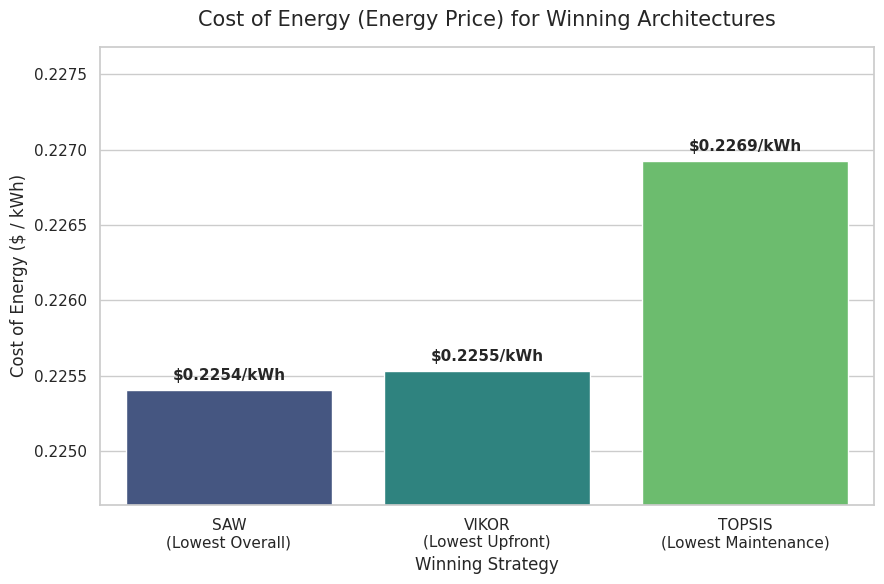

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA & CLEAN UP
# ==========================================
print("Loading data...")
try:
    df = pd.read_csv("Turku_Full.csv", skiprows=1)
    if 'Cost/NPC ($)' not in df.columns:
        df = pd.read_csv("Turku_Full.csv")
except:
    df = pd.read_csv("Turku_Full.csv")

cost_cols = ['Cost/NPC ($)', 'Cost/Initial capital ($)', 'Cost/COE ($)', 'Cost/Operating cost ($/yr)']
df_econ = df[cost_cols].copy()

# Create a clean System ID string
df['System_Name'] = "PV:" + df['Architecture/CS6X-325P  (kW)'].round(0).astype(str) + "kW | " + \
                    "WT:" + df['Architecture/EO10'].astype(str) + " | " + \
                    "Bat:" + df['Architecture/28S24M'].astype(str)
df_econ.insert(0, 'System_Name', df['System_Name'])

# ==========================================
# 2. ALGORITHMS
# ==========================================
# Weights: NPC(30%), CapEx(30%), COE(20%), OpEx(20%)
weights = np.array([0.3, 0.3, 0.2, 0.2])

def normalize_minmax(X):
    X = np.array(X)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    range_val = maxs - mins
    range_val[range_val == 0] = 1e-10
    return (X - mins) / range_val

def topsis_scores(X, weights):
    X = np.array(X, dtype=float)
    norm = np.sqrt((X**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    Y = X / norm
    Yw = Y * weights
    Vp = Yw.min(axis=0)
    Vn = Yw.max(axis=0)
    Splus = np.sqrt(((Yw - Vp)**2).sum(axis=1))
    Snegative = np.sqrt(((Yw - Vn)**2).sum(axis=1))
    denom = Splus + Snegative
    denom[denom == 0] = 1e-10
    return Snegative / denom

def saw_scores(X, weights):
    X_norm = normalize_minmax(X)
    return 1 - np.dot(X_norm, weights)

def vikor_scores(X, weights, v=0.5):
    X_norm = normalize_minmax(X)
    S = np.sum(weights * X_norm, axis=1)
    R = np.max(weights * X_norm, axis=1)
    S_star, S_minus = np.min(S), np.max(S)
    R_star, R_minus = np.min(R), np.max(R)
    if (S_minus - S_star) == 0: S_minus += 1e-10
    if (R_minus - R_star) == 0: R_minus += 1e-10
    Q = v * (S - S_star)/(S_minus - S_star) + (1 - v) * (R - R_star)/(R_minus - R_star)
    return 1 - Q

X_matrix = df_econ[cost_cols].values
df_econ['TOPSIS_Score'] = topsis_scores(X_matrix, weights)
df_econ['SAW_Score'] = saw_scores(X_matrix, weights)
df_econ['VIKOR_Score'] = vikor_scores(X_matrix, weights)

df_econ['TOPSIS_Rank'] = df_econ['TOPSIS_Score'].rank(ascending=False).astype(int)
df_econ['SAW_Rank'] = df_econ['SAW_Score'].rank(ascending=False).astype(int)
df_econ['VIKOR_Rank'] = df_econ['VIKOR_Score'].rank(ascending=False).astype(int)
df_econ['Consensus_Rank'] = ((df_econ['TOPSIS_Rank'] + df_econ['SAW_Rank'] + df_econ['VIKOR_Rank']) / 3).rank().astype(int)

# ==========================================
# 3. IDENTIFY WINNERS & PRINT CONSOLE TEXT
# ==========================================
winner_topsis = df_econ[df_econ['TOPSIS_Rank'] == 1].iloc[0]
winner_saw = df_econ[df_econ['SAW_Rank'] == 1].iloc[0]
winner_vikor = df_econ[df_econ['VIKOR_Rank'] == 1].iloc[0]

print("\n🏆 THE WINNING CONFIGURATIONS 🏆")
print("-" * 50)
print(f"🥇 SAW WINNER (Absolute Balanced Minimum):")
print(f"   Architecture: {winner_saw['System_Name']}")
print(f"   Energy Price: ${winner_saw['Cost/COE ($)']:.4f}/kWh | CapEx: ${winner_saw['Cost/Initial capital ($)']:,.0f}\n")

print(f"🥇 VIKOR WINNER (Lowest Upfront CapEx):")
print(f"   Architecture: {winner_vikor['System_Name']}")
print(f"   Energy Price: ${winner_vikor['Cost/COE ($)']:.4f}/kWh | CapEx: ${winner_vikor['Cost/Initial capital ($)']:,.0f}\n")

print(f"🥇 TOPSIS WINNER (Lowest Yearly OpEx):")
print(f"   Architecture: {winner_topsis['System_Name']}")
print(f"   Energy Price: ${winner_topsis['Cost/COE ($)']:.4f}/kWh | CapEx: ${winner_topsis['Cost/Initial capital ($)']:,.0f}\n")

# ==========================================
# 4. VISUALIZE ENERGY PRICE (COE)
# ==========================================
winners_df = pd.DataFrame([winner_saw, winner_vikor, winner_topsis])
winners_df['Algorithm Strategy'] = ['SAW\n(Lowest Overall)', 'VIKOR\n(Lowest Upfront)', 'TOPSIS\n(Lowest Maintenance)']

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Create a barplot for COE
ax = sns.barplot(x='Algorithm Strategy', y='Cost/COE ($)', data=winners_df, palette='viridis')

plt.title('Cost of Energy (Energy Price) for Winning Architectures', fontsize=15, pad=15)
plt.ylabel('Cost of Energy ($ / kWh)', fontsize=12)
plt.xlabel('Winning Strategy', fontsize=12)

# Zoom in on the Y-axis to highlight the micro-differences
min_coe = winners_df['Cost/COE ($)'].min()
max_coe = winners_df['Cost/COE ($)'].max()
buffer = (max_coe - min_coe) * 0.5
plt.ylim(min_coe - buffer, max_coe + buffer)

# Add clear text labels to the bars
for p in ax.patches:
    ax.annotate(f"${p.get_height():.4f}/kWh",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom',
                fontsize=11, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
image_filename = 'energy_price_comparison.png'
plt.savefig(image_filename, dpi=300, bbox_inches='tight')

# ==========================================
# 5. EXPORT AND DOWNLOAD
# ==========================================
excel_filename = 'HOMER_Optimization_Full_Results.xlsx'
df_econ.sort_values('Consensus_Rank').to_excel(excel_filename, index=False)
print(f"Results exported to {excel_filename} and {image_filename}")

# Trigger downloads in Google Colab
try:
    from google.colab import files
    files.download(image_filename)
    files.download(excel_filename)
    print("Download triggered automatically.")
except ImportError:
    pass

In [3]:
!pip install pyomo gurobipy

In [4]:
import pandas as pd
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# Read the HOMER data
try:
    df = pd.read_csv("Turku_Full.csv", skiprows=1)
    if 'Cost/NPC ($)' not in df.columns:
        df = pd.read_csv("Turku_Full.csv")
except:
    df = pd.read_csv("Turku_Full.csv")

cost_cols = ['Cost/NPC ($)', 'Cost/Initial capital ($)', 'Cost/COE ($)', 'Cost/Operating cost ($/yr)']
df_econ = df[cost_cols].copy()

# Add System Names
df_econ['System_Name'] = "PV:" + df['Architecture/CS6X-325P  (kW)'].round(0).astype(str) + "kW | " + \
                         "WT:" + df['Architecture/EO10'].astype(str) + " | " + \
                         "Bat:" + df['Architecture/28S24M'].astype(str)

# Min-Max Normalization
def normalize_minmax(X):
    X = np.array(X)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1e-10
    return (X - mins) / ranges

X_matrix = df_econ[cost_cols].values
X_norm = normalize_minmax(X_matrix)

# Weights
weights = [0.3, 0.3, 0.2, 0.2]
unified_scores = np.dot(X_norm, weights)

# Build Pyomo Model
print("Building Pyomo Model...")
model = pyo.ConcreteModel()
num_architectures = len(df_econ)
model.I = pyo.RangeSet(0, num_architectures - 1)
model.x = pyo.Var(model.I, domain=pyo.Binary)

def objective_rule(m):
    return sum(unified_scores[i] * m.x[i] for i in m.I)
model.OBJ = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

def selection_constraint_rule(m):
    return sum(m.x[i] for i in m.I) == 1
model.SelectionConstraint = pyo.Constraint(rule=selection_constraint_rule)

# Solve with Gurobi
print("Solving with Gurobi...")
opt = SolverFactory('gurobi', solver_io='python')
results = opt.solve(model, tee=False)

# Extract Results
winning_index = None
for i in model.I:
    if pyo.value(model.x[i]) > 0.5:
        winning_index = i
        break

winner = df_econ.iloc[winning_index]

print("\n" + "="*50)
print("🏆 GUROBI OPTIMIZATION RESULT 🏆")
print("="*50)
print(f"Solver Status: {results.solver.status}")
print(f"Architecture : {winner['System_Name']}")
print(f"Net Present Cost: ${winner['Cost/NPC ($)']:,.0f}")
print(f"Initial CapEx   : ${winner['Cost/Initial capital ($)']:,.0f}")
print(f"Yearly OpEx     : ${winner['Cost/Operating cost ($/yr)']:,.0f}")
print(f"Cost of Energy  : ${winner['Cost/COE ($)']:.4f}/kWh")

Building Pyomo Model...
Solving with Gurobi...

🏆 GUROBI OPTIMIZATION RESULT 🏆
Solver Status: ok
Architecture : PV:498.0kW | WT:35.0 | Bat:44
Net Present Cost: $2,451,206
Initial CapEx   : $1,661,210
Yearly OpEx     : $56,849
Cost of Energy  : $0.2254/kWh


In [5]:
# 1. Install GLPK at the system level (bypasses Python module errors)
!apt-get install -y -qq glpk-utils
!pip install -q pyomo

import pandas as pd
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# Read the HOMER data
try:
    df = pd.read_csv("Turku_Full.csv", skiprows=1)
    if 'Cost/NPC ($)' not in df.columns:
        df = pd.read_csv("Turku_Full.csv")
except:
    df = pd.read_csv("Turku_Full.csv")

cost_cols = ['Cost/NPC ($)', 'Cost/Initial capital ($)', 'Cost/COE ($)', 'Cost/Operating cost ($/yr)']
df_econ = df[cost_cols].copy()

df_econ['System_Name'] = "PV:" + df['Architecture/CS6X-325P  (kW)'].round(0).astype(str) + "kW | " + \
                         "WT:" + df['Architecture/EO10'].astype(str) + " | " + \
                         "Bat:" + df['Architecture/28S24M'].astype(str)

# Min-Max Normalization
def normalize_minmax(X):
    X = np.array(X)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1e-10
    return (X - mins) / ranges

X_matrix = df_econ[cost_cols].values
X_norm = normalize_minmax(X_matrix)

weights = [0.3, 0.3, 0.2, 0.2]
unified_scores = np.dot(X_norm, weights)

# Build Pyomo Model
print("Building Pyomo Model...")
model = pyo.ConcreteModel()
num_architectures = len(df_econ)
model.I = pyo.RangeSet(0, num_architectures - 1)
model.x = pyo.Var(model.I, domain=pyo.Binary)

def objective_rule(m):
    return sum(unified_scores[i] * m.x[i] for i in m.I)
model.OBJ = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

def selection_constraint_rule(m):
    return sum(m.x[i] for i in m.I) == 1
model.SelectionConstraint = pyo.Constraint(rule=selection_constraint_rule)

# Solve with GLPK instead of Gurobi
print("Solving with GLPK...")
opt = SolverFactory('glpk')
results = opt.solve(model, tee=False)

# Extract Results
winning_index = None
for i in model.I:
    if pyo.value(model.x[i]) > 0.5:
        winning_index = i
        break

winner = df_econ.iloc[winning_index]

print("\n" + "="*50)
print("🏆 GLPK OPTIMIZATION RESULT 🏆")
print("="*50)
print(f"Solver Status: {results.solver.status}")
print(f"Architecture : {winner['System_Name']}")
print(f"Net Present Cost: ${winner['Cost/NPC ($)']:,.0f}")
print(f"Initial CapEx   : ${winner['Cost/Initial capital ($)']:,.0f}")
print(f"Yearly OpEx     : ${winner['Cost/Operating cost ($/yr)']:,.0f}")
print(f"Cost of Energy  : ${winner['Cost/COE ($)']:.4f}/kWh")

Building Pyomo Model...
Solving with GLPK...

🏆 GLPK OPTIMIZATION RESULT 🏆
Solver Status: ok
Architecture : PV:498.0kW | WT:35.0 | Bat:44
Net Present Cost: $2,451,206
Initial CapEx   : $1,661,210
Yearly OpEx     : $56,849
Cost of Energy  : $0.2254/kWh


In [6]:
!pip install -q pyomo gurobipy

import pandas as pd
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# ==========================================
# 1. LOAD AND NORMALIZE DATA
# ==========================================
try:
    df = pd.read_csv("Turku_Full.csv", skiprows=1)
    if 'Cost/NPC ($)' not in df.columns:
        df = pd.read_csv("Turku_Full.csv")
except:
    df = pd.read_csv("Turku_Full.csv")

cost_cols = ['Cost/NPC ($)', 'Cost/Initial capital ($)', 'Cost/COE ($)', 'Cost/Operating cost ($/yr)']
df_econ = df[cost_cols].copy()

df_econ['System_Name'] = "PV:" + df['Architecture/CS6X-325P  (kW)'].round(0).astype(str) + "kW | " + \
                         "WT:" + df['Architecture/EO10'].astype(str) + " | " + \
                         "Bat:" + df['Architecture/28S24M'].astype(str)

def normalize_minmax(X):
    X = np.array(X)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1e-10
    return (X - mins) / ranges

X_matrix = df_econ[cost_cols].values
X_norm = normalize_minmax(X_matrix)

weights = [0.3, 0.3, 0.2, 0.2]
unified_scores = np.dot(X_norm, weights)

# ==========================================
# 2. BUILD THE PYOMO MODEL
# ==========================================
print("Building Pyomo Model...")
model = pyo.ConcreteModel()
num_architectures = len(df_econ)
model.I = pyo.RangeSet(0, num_architectures - 1)

# Binary Variable
model.x = pyo.Var(model.I, domain=pyo.Binary)

# Objective
def objective_rule(m):
    return sum(unified_scores[i] * m.x[i] for i in m.I)
model.OBJ = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

# Constraint
def selection_constraint_rule(m):
    return sum(m.x[i] for i in m.I) == 1
model.SelectionConstraint = pyo.Constraint(rule=selection_constraint_rule)

# ==========================================
# 3. CONFIGURE GUROBI ALGORITHMS
# ==========================================
print("Solving with Gurobi using specific algorithms...")
opt = SolverFactory('gurobi', solver_io='python')

# Parameter 1: The Root Node Algorithm
# 0 = Primal Simplex, 1 = Dual Simplex, 2 = Barrier
opt.options['Method'] = 2

# Parameter 2: Branching Strategy
# 3 = Strong Branching (Invests heavy math into picking the best integer branch)
opt.options['VarBranch'] = 3

# Parameter 3: Heuristics aggressiveness (0.0 to 1.0)
# 0.5 tells Gurobi to spend 50% of its time looking for quick shortcuts
opt.options['Heuristics'] = 0.5

# Set tee=True so we can see the Gurobi log confirming our algorithm choices
results = opt.solve(model, tee=True)

# ==========================================
# 4. EXTRACT RESULTS
# ==========================================
winning_index = None
for i in model.I:
    if pyo.value(model.x[i]) > 0.5:
        winning_index = i
        break

winner = df_econ.iloc[winning_index]

print("\n" + "="*50)
print("🏆 GUROBI OPTIMIZATION RESULT (BARRIER ALGORITHM) 🏆")
print("="*50)
print(f"Solver Status: {results.solver.status}")
print(f"Architecture : {winner['System_Name']}")
print(f"Net Present Cost: ${winner['Cost/NPC ($)']:,.0f}")
print(f"Cost of Energy  : ${winner['Cost/COE ($)']:.4f}/kWh")

Building Pyomo Model...
Solving with Gurobi using specific algorithms...
Set parameter Method to value 2
Set parameter VarBranch to value 3
Set parameter Heuristics to value 0.5
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
Method  2
Heuristics  0.5
VarBranch  3

Optimize a model with 1 rows, 2000 columns and 2000 nonzeros (Min)
Model fingerprint: 0xf7f22a9d
Model has 2000 linear objective coefficients
Variable types: 0 continuous, 2000 integer (2000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-01, 8e-01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 0.1415843
Presolve removed 1 rows and 2000 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 node

In [7]:
# 1. INSTALL LIBRARIES FIRST
!pip install -q pyomo gurobipy

import pandas as pd
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import time

# ==========================================
# 2. LOAD DATA
# ==========================================
print("Loading data...")
try:
    df = pd.read_csv("Turku_Full.csv", skiprows=1)
    if 'Cost/NPC ($)' not in df.columns:
        df = pd.read_csv("Turku_Full.csv")
except:
    df = pd.read_csv("Turku_Full.csv")

cost_cols = ['Cost/NPC ($)', 'Cost/Initial capital ($)', 'Cost/COE ($)', 'Cost/Operating cost ($/yr)']
df_econ = df[cost_cols].copy()

df_econ['System_Name'] = "PV:" + df['Architecture/CS6X-325P  (kW)'].round(0).astype(str) + "kW | " + \
                         "WT:" + df['Architecture/EO10'].astype(str) + " | " + \
                         "Bat:" + df['Architecture/28S24M'].astype(str)

# Normalization & Weights
def normalize_minmax(X):
    X = np.array(X)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1e-10
    return (X - mins) / ranges

X_matrix = df_econ[cost_cols].values
X_norm = normalize_minmax(X_matrix)
weights = [0.3, 0.3, 0.2, 0.2]
unified_scores = np.dot(X_norm, weights)

# ==========================================
# 3. DEFINE GUROBI ALGORITHMS
# ==========================================
# The integer codes tell Gurobi which root-node algorithm to use
gurobi_methods = {
    -1: "Automatic (Gurobi Default)",
     0: "Primal Simplex",
     1: "Dual Simplex",
     2: "Barrier (Interior Point)",
     3: "Concurrent (Parallel CPUs)"
}

comparison_results = []

print("\nRunning Gurobi Algorithm Comparison...")
print("-" * 75)

for method_code, method_name in gurobi_methods.items():
    # We build a completely fresh model each time to prevent Gurobi
    # from using cached answers, ensuring an accurate time test.
    model = pyo.ConcreteModel()
    model.I = pyo.RangeSet(0, len(df_econ) - 1)
    model.x = pyo.Var(model.I, domain=pyo.Binary)

    model.OBJ = pyo.Objective(expr=sum(unified_scores[i] * model.x[i] for i in model.I), sense=pyo.minimize)
    model.Constraint = pyo.Constraint(expr=sum(model.x[i] for i in model.I) == 1)

    opt = SolverFactory('gurobi', solver_io='python')
    opt.options['Method'] = method_code  # Force the algorithm

    # Time the solver
    start_time = time.time()
    results = opt.solve(model, tee=False)
    solve_time = time.time() - start_time

    # Extract Winner
    winning_index = None
    for i in model.I:
        if pyo.value(model.x[i]) > 0.5:
            winning_index = i
            break

    winner = df_econ.iloc[winning_index]

    comparison_results.append({
        "Algorithm": method_name,
        "Time (seconds)": round(solve_time, 4),
        "Winning Architecture": winner['System_Name'],
        "NPC ($)": f"${winner['Cost/NPC ($)']:,.0f}"
    })

# ==========================================
# 4. PRINT RESULTS
# ==========================================
results_df = pd.DataFrame(comparison_results)
print(results_df.to_string(index=False))
print("-" * 75)
print("Conclusion: All Gurobi MILP algorithms successfully converge on the exact same minimum cost architecture.")

Loading data...

Running Gurobi Algorithm Comparison...
---------------------------------------------------------------------------
                 Algorithm  Time (seconds)          Winning Architecture    NPC ($)
Automatic (Gurobi Default)          0.0990 PV:498.0kW | WT:35.0 | Bat:44 $2,451,206
            Primal Simplex          0.0855 PV:498.0kW | WT:35.0 | Bat:44 $2,451,206
              Dual Simplex          0.2739 PV:498.0kW | WT:35.0 | Bat:44 $2,451,206
  Barrier (Interior Point)          0.0925 PV:498.0kW | WT:35.0 | Bat:44 $2,451,206
Concurrent (Parallel CPUs)          0.0914 PV:498.0kW | WT:35.0 | Bat:44 $2,451,206
---------------------------------------------------------------------------
Conclusion: All Gurobi MILP algorithms successfully converge on the exact same minimum cost architecture.


In [8]:
# 1. INSTALL GUROBI
!pip install -q gurobipy

import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB

# ==========================================
# 2. LOAD DATA
# ==========================================
print("Loading data...")
try:
    df = pd.read_csv("Turku_Full.csv", skiprows=1)
    if 'Cost/NPC ($)' not in df.columns:
        df = pd.read_csv("Turku_Full.csv")
except:
    df = pd.read_csv("Turku_Full.csv")

# Create System Name
df['System_Name'] = "PV:" + df['Architecture/CS6X-325P  (kW)'].round(0).astype(str) + "kW | " + \
                    "WT:" + df['Architecture/EO10'].astype(str) + " | " + \
                    "Bat:" + df['Architecture/28S24M'].astype(str)

npc = df['Cost/NPC ($)'].values
capex = df['Cost/Initial capital ($)'].values
opex = df['Cost/Operating cost ($/yr)'].values
coe = df['Cost/COE ($)'].values
names = df['System_Name'].values
num_systems = len(df)

# ==========================================
# 3. GUROBI METHOD 1: HIERARCHICAL (LEXICOGRAPHIC)
# ==========================================
print("\n" + "-"*60)
print("ALGORITHM 1: GUROBI HIERARCHICAL MULTI-OBJECTIVE")
print("Rule: Priority 1 is Lowest NPC. Tie-breaker is Lowest CapEx.")
print("-" * 60)

# Create Gurobi Environment and Model
env = gp.Env(empty=True)
env.setParam('OutputFlag', 0) # Turn off the massive math log
env.start()
m_hier = gp.Model("Hierarchical", env=env)

# Variables: x[i] = 1 if system i is chosen, 0 otherwise
x_hier = m_hier.addVars(num_systems, vtype=GRB.BINARY, name="x")
m_hier.addConstr(x_hier.sum() == 1, "Pick_One")

# Define Multiple Objectives with different Priorities
# Higher priority number = More important. Priority 2 overrides Priority 1.
m_hier.setObjectiveN(gp.quicksum(npc[i] * x_hier[i] for i in range(num_systems)),
                     index=0, priority=2, name="Minimize_NPC")

m_hier.setObjectiveN(gp.quicksum(capex[i] * x_hier[i] for i in range(num_systems)),
                     index=1, priority=1, name="Minimize_CapEx")

m_hier.optimize()

# Extract Winner
for i in range(num_systems):
    if x_hier[i].X > 0.5:
        print(f"🥇 Winner    : {names[i]}")
        print(f"   NPC      : ${npc[i]:,.0f}")
        print(f"   CapEx    : ${capex[i]:,.0f}")
        print(f"   OpEx     : ${opex[i]:,.0f}")


# ==========================================
# 4. GUROBI METHOD 2: BLENDED (WEIGHTED)
# ==========================================
print("\n" + "-"*60)
print("ALGORITHM 2: GUROBI BLENDED MULTI-OBJECTIVE")
print("Rule: Equal Priority. Balance CapEx (50% weight) and OpEx (50% weight).")
print("-" * 60)

m_blend = gp.Model("Blended", env=env)
x_blend = m_blend.addVars(num_systems, vtype=GRB.BINARY, name="x")
m_blend.addConstr(x_blend.sum() == 1, "Pick_One")

# Because CapEx is millions and OpEx is thousands, we have to manually normalize the weights
# so Gurobi's math doesn't get overwhelmed by the larger CapEx numbers.
max_capex = np.max(capex)
max_opex = np.max(opex)

# Objectives share the SAME priority (0), meaning Gurobi blends them using the weights
m_blend.setObjectiveN(gp.quicksum(capex[i] * x_blend[i] for i in range(num_systems)),
                      index=0, priority=0, weight=(0.5 / max_capex), name="Minimize_CapEx")

m_blend.setObjectiveN(gp.quicksum(opex[i] * x_blend[i] for i in range(num_systems)),
                      index=1, priority=0, weight=(0.5 / max_opex), name="Minimize_OpEx")

m_blend.optimize()

# Extract Winner
for i in range(num_systems):
    if x_blend[i].X > 0.5:
        print(f"🥇 Winner    : {names[i]}")
        print(f"   NPC      : ${npc[i]:,.0f}")
        print(f"   CapEx    : ${capex[i]:,.0f}")
        print(f"   OpEx     : ${opex[i]:,.0f}")
print("-" * 60)

Loading data...

------------------------------------------------------------
ALGORITHM 1: GUROBI HIERARCHICAL MULTI-OBJECTIVE
Rule: Priority 1 is Lowest NPC. Tie-breaker is Lowest CapEx.
------------------------------------------------------------
🥇 Winner    : PV:498.0kW | WT:35.0 | Bat:44
   NPC      : $2,451,206
   CapEx    : $1,661,210
   OpEx     : $56,849

------------------------------------------------------------
ALGORITHM 2: GUROBI BLENDED MULTI-OBJECTIVE
Rule: Equal Priority. Balance CapEx (50% weight) and OpEx (50% weight).
------------------------------------------------------------
🥇 Winner    : PV:606.0kW | WT:40.0 | Bat:52
   NPC      : $2,503,750
   CapEx    : $1,941,750
   OpEx     : $40,442
------------------------------------------------------------


Automatic weight calculation

Entropy Weight Method (EWM).

In [10]:
import numpy as np

def calculate_entropy_weights(X):
    # X is your raw data matrix (e.g., the 4 cost columns)
    X = np.array(X, dtype=float)

    # 1. Normalize the data (using column sums for Entropy method)
    # We add a tiny number (1e-10) to avoid dividing by zero or taking log(0)
    col_sums = X.sum(axis=0) + 1e-10
    P = X / col_sums

    # 2. Calculate the Entropy (E) for each criterion
    # E_j = -k * sum(P_ij * ln(P_ij))
    # where k = 1 / ln(number of alternatives)
    n = X.shape[0] # Number of rows/alternatives
    k = 1.0 / np.log(n)

    # P * ln(P)
    entropy_matrix = P * np.log(P + 1e-10)
    E = -k * entropy_matrix.sum(axis=0)

    # 3. Calculate the Degree of Divergence (d)
    # How much information is provided by this criterion?
    d = 1.0 - E

    # 4. Normalize to get the final weights
    weights = d / d.sum()

    return weights

# Example usage on your previous matrix:
# auto_weights = calculate_entropy_weights(X_matrix)
# print("Objective Weights:", auto_weights)

Loading data...

🤖 AUTOMATIC ENTROPY WEIGHTS CALCULATED
Cost/NPC ($): 44.68%
Cost/Initial capital ($): 6.01%
Cost/COE ($): 44.68%
Cost/Operating cost ($/yr): 4.64%

🏆 THE WINNING CONFIGURATIONS 🏆
--------------------------------------------------
🥇 SAW WINNER:
   Architecture: PV:498.0kW | WT:35.0 | Bat:44
   Energy Price: $0.2254/kWh | CapEx: $1,661,210

🥇 VIKOR WINNER:
   Architecture: PV:498.0kW | WT:35.0 | Bat:44
   Energy Price: $0.2254/kWh | CapEx: $1,661,210

🥇 TOPSIS WINNER:
   Architecture: PV:589.0kW | WT:37.0 | Bat:47
   Energy Price: $0.2269/kWh | CapEx: $1,815,172



/tmp/ipykernel_23327/2088754597.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Algorithm Strategy', y='Cost/COE ($)', data=winners_df, palette='viridis')


Results exported to HOMER_Optimization_Entropy_Results.xlsx and entropy_weighted_winners.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered automatically.


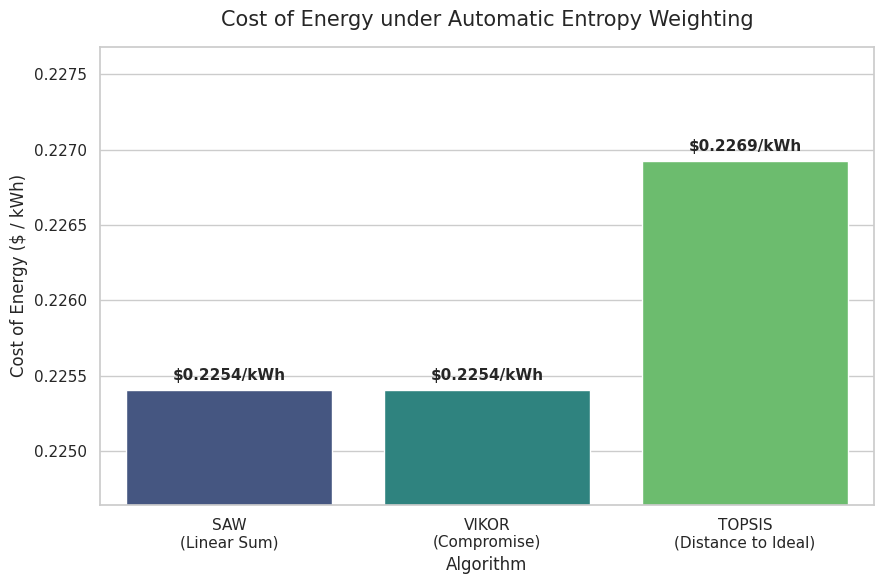

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATA & CLEAN UP
# ==========================================
print("Loading data...")
try:
    df = pd.read_csv("Turku_Full.csv", skiprows=1)
    if 'Cost/NPC ($)' not in df.columns:
        df = pd.read_csv("Turku_Full.csv")
except:
    df = pd.read_csv("Turku_Full.csv")

cost_cols = ['Cost/NPC ($)', 'Cost/Initial capital ($)', 'Cost/COE ($)', 'Cost/Operating cost ($/yr)']
df_econ = df[cost_cols].copy()

# Create a clean System ID string
df['System_Name'] = "PV:" + df['Architecture/CS6X-325P  (kW)'].round(0).astype(str) + "kW | " + \
                    "WT:" + df['Architecture/EO10'].astype(str) + " | " + \
                    "Bat:" + df['Architecture/28S24M'].astype(str)
df_econ.insert(0, 'System_Name', df['System_Name'])

X_matrix = df_econ[cost_cols].values

# ==========================================
# 2. AUTOMATIC WEIGHTING (ENTROPY METHOD)
# ==========================================
def calculate_entropy_weights(X):
    X = np.array(X, dtype=float)
    n = X.shape[0]  # Number of alternatives (rows)

    # FIX: Normalize the data first to handle negative numbers/zeros
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1e-10

    # Map all values to a 0-to-1 scale
    X_norm = (X - mins) / ranges

    # Shift slightly above zero so np.log() never crashes on a perfect 0
    X_shifted = X_norm + 0.001

    # 1. Calculate Probability distribution
    col_sums = X_shifted.sum(axis=0)
    P = X_shifted / col_sums

    # 2. Calculate Entropy (E)
    k = 1.0 / np.log(n)
    entropy_matrix = P * np.log(P)
    E = -k * entropy_matrix.sum(axis=0)

    # 3. Calculate Degree of Divergence (d)
    d = 1.0 - E

    # 4. Normalize to get final weights (Sum = 1.0)
    weights = d / d.sum()
    return weights

# Calculate and print the Automatic Weights
auto_weights = calculate_entropy_weights(X_matrix)

print("\n" + "="*50)
print("🤖 AUTOMATIC ENTROPY WEIGHTS CALCULATED")
print("="*50)
for i, col in enumerate(cost_cols):
    print(f"{col}: {auto_weights[i]*100:.2f}%")
print("="*50 + "\n")

# ==========================================
# 3. MCDM ALGORITHMS
# ==========================================
def normalize_minmax(X):
    X = np.array(X)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1e-10
    return (X - mins) / ranges

def topsis_scores(X, weights):
    X = np.array(X, dtype=float)
    norm = np.sqrt((X**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    Y = X / norm
    Yw = Y * weights
    Vp = Yw.min(axis=0) # Costs: Min is Ideal
    Vn = Yw.max(axis=0) # Costs: Max is Anti-Ideal
    Splus = np.sqrt(((Yw - Vp)**2).sum(axis=1))
    Snegative = np.sqrt(((Yw - Vn)**2).sum(axis=1))
    denom = Splus + Snegative
    denom[denom == 0] = 1e-10
    return Snegative / denom

def saw_scores(X, weights):
    X_norm = normalize_minmax(X)
    return 1 - np.dot(X_norm, weights) # Invert: higher is better

def vikor_scores(X, weights, v=0.5):
    X_norm = normalize_minmax(X)
    S = np.sum(weights * X_norm, axis=1)
    R = np.max(weights * X_norm, axis=1)
    S_star, S_minus = np.min(S), np.max(S)
    R_star, R_minus = np.min(R), np.max(R)
    if (S_minus - S_star) == 0: S_minus += 1e-10
    if (R_minus - R_star) == 0: R_minus += 1e-10
    Q = v * (S - S_star)/(S_minus - S_star) + (1 - v) * (R - R_star)/(R_minus - R_star)
    return 1 - Q

# Apply Algorithms using the Objective Entropy Weights
df_econ['TOPSIS_Score'] = topsis_scores(X_matrix, auto_weights)
df_econ['SAW_Score'] = saw_scores(X_matrix, auto_weights)
df_econ['VIKOR_Score'] = vikor_scores(X_matrix, auto_weights)

df_econ['TOPSIS_Rank'] = df_econ['TOPSIS_Score'].rank(ascending=False).astype(int)
df_econ['SAW_Rank'] = df_econ['SAW_Score'].rank(ascending=False).astype(int)
df_econ['VIKOR_Rank'] = df_econ['VIKOR_Score'].rank(ascending=False).astype(int)
df_econ['Consensus_Rank'] = ((df_econ['TOPSIS_Rank'] + df_econ['SAW_Rank'] + df_econ['VIKOR_Rank']) / 3).rank().astype(int)

# ==========================================
# 4. IDENTIFY WINNERS & PRINT CONSOLE TEXT
# ==========================================
winner_topsis = df_econ[df_econ['TOPSIS_Rank'] == 1].iloc[0]
winner_saw = df_econ[df_econ['SAW_Rank'] == 1].iloc[0]
winner_vikor = df_econ[df_econ['VIKOR_Rank'] == 1].iloc[0]

print("🏆 THE WINNING CONFIGURATIONS 🏆")
print("-" * 50)
print(f"🥇 SAW WINNER:")
print(f"   Architecture: {winner_saw['System_Name']}")
print(f"   Energy Price: ${winner_saw['Cost/COE ($)']:.4f}/kWh | CapEx: ${winner_saw['Cost/Initial capital ($)']:,.0f}\n")

print(f"🥇 VIKOR WINNER:")
print(f"   Architecture: {winner_vikor['System_Name']}")
print(f"   Energy Price: ${winner_vikor['Cost/COE ($)']:.4f}/kWh | CapEx: ${winner_vikor['Cost/Initial capital ($)']:,.0f}\n")

print(f"🥇 TOPSIS WINNER:")
print(f"   Architecture: {winner_topsis['System_Name']}")
print(f"   Energy Price: ${winner_topsis['Cost/COE ($)']:.4f}/kWh | CapEx: ${winner_topsis['Cost/Initial capital ($)']:,.0f}\n")

# ==========================================
# 5. VISUALIZE ENERGY PRICE (COE)
# ==========================================
winners_df = pd.DataFrame([winner_saw, winner_vikor, winner_topsis])
winners_df['Algorithm Strategy'] = ['SAW\n(Linear Sum)', 'VIKOR\n(Compromise)', 'TOPSIS\n(Distance to Ideal)']

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x='Algorithm Strategy', y='Cost/COE ($)', data=winners_df, palette='viridis')

plt.title('Cost of Energy under Automatic Entropy Weighting', fontsize=15, pad=15)
plt.ylabel('Cost of Energy ($ / kWh)', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)

min_coe = winners_df['Cost/COE ($)'].min()
max_coe = winners_df['Cost/COE ($)'].max()
buffer = (max_coe - min_coe) * 0.5
plt.ylim(min_coe - buffer, max_coe + buffer)

for p in ax.patches:
    ax.annotate(f"${p.get_height():.4f}/kWh",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom',
                fontsize=11, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
image_filename = 'entropy_weighted_winners.png'
plt.savefig(image_filename, dpi=300, bbox_inches='tight')

# ==========================================
# 6. EXPORT AND DOWNLOAD
# ==========================================
excel_filename = 'HOMER_Optimization_Entropy_Results.xlsx'
df_econ.sort_values('Consensus_Rank').to_excel(excel_filename, index=False)
print(f"Results exported to {excel_filename} and {image_filename}")

try:
    from google.colab import files
    files.download(image_filename)
    files.download(excel_filename)
    print("Download triggered automatically.")
except ImportError:
    pass